# Cost Function and Gradient Descent

## Objective

In this notebook, we will understand how a Linear Regression model learns
the best parameters by minimizing the Cost Function using Gradient Descent.

Instead of directly calculating the best parameters using the Normal
Equation, Gradient Descent will update the parameters step by step.

### Topics

- Understanding the Cost Function
- Mean Squared Error and Cost Function
- Understanding the Gradient
- Understanding the Gradient Descent algorithm
- Updating weights and intercept
- Implementing Gradient Descent from scratch
- Visualizing the cost over iterations

## Cost Function

The Cost Function measures how well our Linear Regression model is
performing.

For Linear Regression, we commonly use Mean Squared Error (MSE):

MSE = (1/n) Σ(yᵢ - ŷᵢ)²

However, when deriving Gradient Descent, we commonly use the following
Cost Function:

J(θ) = (1/2n) Σ(yᵢ - ŷᵢ)²

The factor `1/2` is used because it makes the derivative simpler.

A smaller cost means that the predictions are closer to the actual
values.

Our goal is to find the model parameters that minimize the Cost Function.

## Prediction Equation

For Multiple Linear Regression, the prediction is calculated as:

ŷ = b + w₁x₁ + w₂x₂ + ... + wₙxₙ

Where:

- `ŷ` = predicted value
- `b` = intercept
- `w` = model coefficients (weights)
- `x` = input features
- `n` = number of features

During Gradient Descent, the values of `w` and `b` are repeatedly updated
so that the Cost Function becomes smaller.

The model starts with initial values for the parameters and gradually
moves toward values that minimize the Cost Function.


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [55]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [56]:
X = df.iloc[:,0:8]
y = df.iloc[:,-1]

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


## Feature Scaling

Gradient Descent is sensitive to the scale of input features.

In our dataset, different features have very different numerical ranges.
For example, `Population` can have much larger values than `MedInc`.

If the features have very different scales, Gradient Descent may take
uneven steps toward the minimum of the Cost Function and can converge
slowly.

Therefore, we will use **Standardization** before applying Gradient
Descent.

The Standardization formula is:

z = (x - μ) / σ

Where:

- `x` = original feature value
- `μ` = mean of the feature
- `σ` = standard deviation of the feature
- `z` = standardized feature value

The scaler must be fitted only on the training data to avoid data leakage.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

(16512, 8)
(4128, 8)
[-2.34954175e-16  1.04997836e-16 -4.56138142e-16 -1.60078669e-16
  3.74377532e-17  4.26015812e-17  4.04499862e-17 -3.17145104e-15]
[1. 1. 1. 1. 1. 1. 1. 1.]


## Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the Cost
Function.

The gradient tells us the direction in which the Cost Function increases
the most.

Therefore, to minimize the Cost Function, we move in the opposite
direction of the gradient.

The general update rule is:

θ = θ - α × gradient

Where:

- `θ` = model parameter
- `α` = learning rate
- `gradient` = derivative of the Cost Function with respect to the parameter

For Linear Regression, we update both the weights and the intercept.

The learning rate controls the size of each update:

- A very small learning rate can make training slow.
- A very large learning rate can cause the algorithm to overshoot the
  minimum or become unstable.

Gradient Descent repeatedly updates the parameters until the Cost Function
converges toward a minimum.

## Gradients for Linear Regression

For the Cost Function:

J = (1/2n) Σ(yᵢ - ŷᵢ)²

and prediction:

ŷᵢ = b + w₁xᵢ₁ + w₂xᵢ₂ + ... + wₙxᵢₙ

the gradients are:

### Gradient with respect to the intercept

∂J/∂b = -(1/n) Σ(yᵢ - ŷᵢ)

### Gradient with respect to the weights

∂J/∂wⱼ = -(1/n) Σ(yᵢ - ŷᵢ)xᵢⱼ

The parameters are then updated using:

b = b - α(∂J/∂b)

wⱼ = wⱼ - α(∂J/∂wⱼ)

In our implementation, we use `-2` instead of `-1` in the gradients
because our code uses the Mean Squared Error form without the `1/2`
factor.

The important idea is that the gradients tell us how much each parameter
should change to reduce the Cost Function.

In [61]:
class GDRegressor:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X_train, y_train):

        # Initialize parameters
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        # Gradient Descent
        for i in range(self.epochs):

            # Make predictions
            y_hat = np.dot(X_train, self.coef_) + self.intercept_

            # Calculate gradients
            intercept_der = -2 * np.mean(y_train - y_hat)

            coef_der = (
                -2 * np.dot((y_train - y_hat), X_train)
                / X_train.shape[0]
            )

            # Update parameters
            self.intercept_ = (
                self.intercept_
                - self.learning_rate * intercept_der
            )

            self.coef_ = (
                self.coef_
                - self.learning_rate * coef_der
            )

            # Calculate cost
            cost = np.mean((y_train - y_hat) ** 2) / 2

            # Store cost
            self.cost_history.append(cost)

    def predict(self, X_test):

        return np.dot(X_test, self.coef_) + self.intercept_

In [62]:
gd = GDRegressor(learning_rate=0.1, epochs=1000)

gd.fit(X_train_scaled, y_train)

print("Intercept:", gd.intercept_)
print("Coefficients:", gd.coef_)
print("Number of costs:", len(gd.cost_history))

Intercept: 2.069673255813951
Coefficients: [ 0.83254328  0.11813026 -0.25461415  0.28526899 -0.00621265 -0.03995341
 -0.9056147  -0.87825565]
Number of costs: 1000


In [63]:
print("First cost:", gd.cost_history[0])
print("Last cost:", gd.cost_history[-1])

First cost: 5.517414129495783
Last cost: 0.2622234976327052


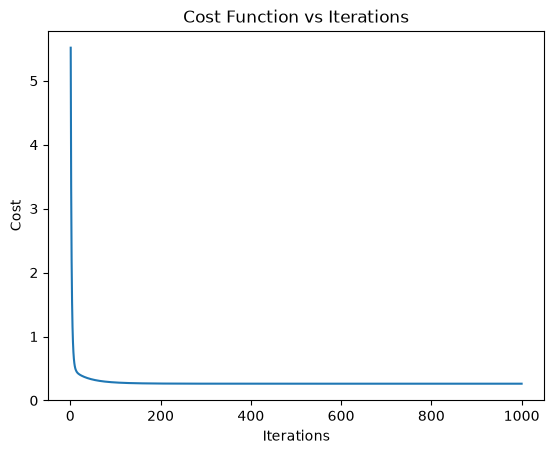

In [64]:
plt.plot(range(1, gd.epochs + 1), gd.cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function vs Iterations")

plt.show()

In [65]:
y_pred_gd = gd.predict(X_test_scaled)

In [66]:
print(y_pred_gd.shape)
print(y_pred_gd[:5])

(4128,)
[2.06299948 2.50552447 1.61458768 1.39378502 2.59929054]


In [67]:
mse = np.sum((y_test - y_pred_gd)**2) / y_test.shape[0]
print(f"MSE: {mse}")

MSE: 0.5250092184091937


In [68]:
rmse = np.sqrt(np.sum((y_test - y_pred_gd)**2) / y_test.shape[0])
print(f"RMSE : {rmse}")

RMSE : 0.7245751985882443


In [69]:
num = np.sum((y_test - y_pred_gd)**2)
den = np.sum((y_test - y_test.mean())**2)

r2 = 1 - (num / den)

print(f"R2_Score: {r2}")

R2_Score: 0.5964027797489585


## Gradient Descent Convergence

After increasing the number of epochs to 1000, the Gradient Descent model
converged much closer to the optimal solution.

The final results are:

- MSE ≈ **0.5250**
- RMSE ≈ **0.7246**
- R² ≈ **0.5964**

These results are almost identical to the results obtained using the
Normal Equation.

This demonstrates that Gradient Descent can learn parameters that produce
a solution very close to the analytical solution when the learning rate
and number of iterations are chosen appropriately.

The Cost Function also decreases rapidly at the beginning and then
gradually approaches a stable value, indicating convergence.


## Why This Is Batch Gradient Descent

The Gradient Descent implementation in this notebook uses the complete
training dataset to calculate the gradients at every iteration.

For each epoch:

1. Predictions are calculated for all training samples.
2. The gradients are calculated using all training samples.
3. The coefficients and intercept are updated.
4. The Cost Function is recorded.

Because the complete training dataset is used for every parameter update,
this method is called **Batch Gradient Descent**.

### Batch Gradient Descent

- Uses all training samples for one update.
- Produces a stable and consistent gradient.
- Can be computationally expensive for very large datasets.
- The learning process is controlled by the learning rate and number of
  epochs.

In the next stages of the project, we will compare Batch Gradient Descent
with Stochastic Gradient Descent and Mini-Batch Gradient Descent.

## Final Summary

- Understood the Cost Function used in Linear Regression.
- Learned how Gradient Descent minimizes the Cost Function.
- Standardized the input features before training.
- Initialized the coefficients and intercept.
- Implemented Batch Gradient Descent from scratch.
- Calculated gradients for the coefficients and intercept.
- Updated the parameters iteratively using the learning rate.
- Stored the Cost Function value after each iteration.
- Visualized the decrease in Cost Function over 1000 iterations.
- Evaluated the model using MSE, RMSE, and R².
- With 1000 epochs, the model achieved approximately:
  - MSE = **0.5250**
  - RMSE = **0.7246**
  - R² = **0.5964**
- The results were almost identical to the Normal Equation implementation.
- This confirms that our Batch Gradient Descent implementation successfully
  learned a near-optimal solution.
  